In [1]:
# End to End Delivery Time Prediction

In [7]:
#!pip install catboost

In [8]:
#!pip install geopy

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from geopy.distance import geodesic
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor

warnings.filterwarnings("ignore")


In [2]:
train_df = pd.read_csv('DeliveryTime/train.csv')

In [3]:
train_df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,Time_Order_picked,Weatherconditions,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken(min)
0,0x4607,INDORES13DEL02,37,4.9,22.745049,75.892471,22.765049,75.912471,19-03-2022,11:30:00,11:45:00,conditions Sunny,High,2,Snack,motorcycle,0,No,Urban,(min) 24
1,0xb379,BANGRES18DEL02,34,4.5,12.913041,77.683237,13.043041,77.813237,25-03-2022,19:45:00,19:50:00,conditions Stormy,Jam,2,Snack,scooter,1,No,Metropolitian,(min) 33
2,0x5d6d,BANGRES19DEL01,23,4.4,12.914264,77.678400,12.924264,77.688400,19-03-2022,08:30:00,08:45:00,conditions Sandstorms,Low,0,Drinks,motorcycle,1,No,Urban,(min) 26
3,0x7a6a,COIMBRES13DEL02,38,4.7,11.003669,76.976494,11.053669,77.026494,05-04-2022,18:00:00,18:10:00,conditions Sunny,Medium,0,Buffet,motorcycle,1,No,Metropolitian,(min) 21
4,0x70a2,CHENRES12DEL01,32,4.6,12.972793,80.249982,13.012793,80.289982,26-03-2022,13:30:00,13:45:00,conditions Cloudy,High,1,Snack,scooter,1,No,Metropolitian,(min) 30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45588,0x7c09,JAPRES04DEL01,30,4.8,26.902328,75.794257,26.912328,75.804257,24-03-2022,11:35:00,11:45:00,conditions Windy,High,1,Meal,motorcycle,0,No,Metropolitian,(min) 32
45589,0xd641,AGRRES16DEL01,21,4.6,0.000000,0.000000,0.070000,0.070000,16-02-2022,19:55:00,20:10:00,conditions Windy,Jam,0,Buffet,motorcycle,1,No,Metropolitian,(min) 36
45590,0x4f8d,CHENRES08DEL03,30,4.9,13.022394,80.242439,13.052394,80.272439,11-03-2022,23:50:00,00:05:00,conditions Cloudy,Low,1,Drinks,scooter,0,No,Metropolitian,(min) 16
45591,0x5eee,COIMBRES11DEL01,20,4.7,11.001753,76.986241,11.041753,77.026241,07-03-2022,13:35:00,13:40:00,conditions Cloudy,High,0,Snack,motorcycle,1,No,Metropolitian,(min) 26


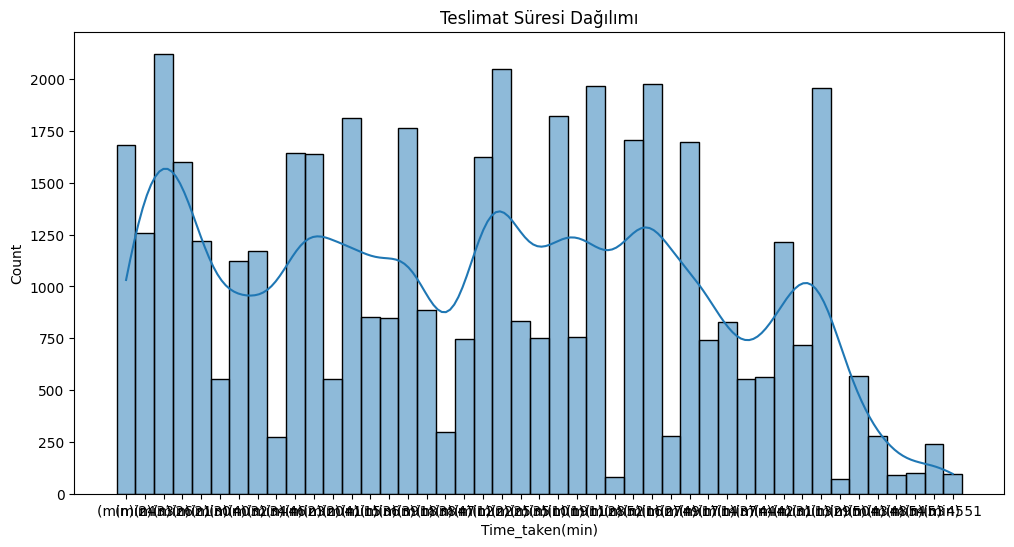

In [4]:

plt.figure(figsize=(12,6))
sns.histplot(train_df['Time_taken(min)'], kde=True)
plt.title('Teslimat Süresi Dağılımı')
plt.show()

# Diğer görselleştirmeleriniz burada aynı mantıkla devam edebilir...

In [5]:
def prepare_data(df):
    # Hedef değişkeni temizle
    df['Time_taken(min)'] = df['Time_taken(min)'].apply(lambda x: int(x.split(' ')[1]) if isinstance(x, str) else x)
    
    # Mesafe hesaplama
    df['distance'] = df.apply(lambda x: geodesic((x['Restaurant_latitude'], x['Restaurant_longitude']), 
                                                 (x['Delivery_location_latitude'], x['Delivery_location_longitude'])).km, axis=1)
    
    # Zaman özellikleri
    df['Order_Date'] = pd.to_datetime(df['Order_Date'], format='%d-%m-%Y')
    df['day'] = df['Order_Date'].dt.day
    df['month'] = df['Order_Date'].dt.month
    df['day_of_week'] = df['Order_Date'].dt.dayofweek
    
    return df

train_df = prepare_data(train_df)

In [6]:
def fix_dtypes(df):
    cols_to_fix = ['Delivery_person_Age', 'Delivery_person_Ratings', 'multiple_deliveries']
    
    for col in cols_to_fix:
        # Önce verideki boşlukları veya 'NaN' yazan metinleri gerçek NaN yapalım
        df[col] = pd.to_numeric(df[col], errors='coerce')
        
    # Eksik verileri (NaN) dolduralım (Median veya 0 ile)
    df['Delivery_person_Age'] = df['Delivery_person_Age'].fillna(df['Delivery_person_Age'].median())
    df['Delivery_person_Ratings'] = df['Delivery_person_Ratings'].fillna(df['Delivery_person_Ratings'].mean())
    df['multiple_deliveries'] = df['multiple_deliveries'].fillna(0)
    
    return df

train_df = fix_dtypes(train_df)

In [7]:
# Sözlükleri kullanarak metinleri anlamlı sayılara çevirelim
traffic_map = {'Low': 1, 'Medium': 2, 'High': 3, 'Jam': 4}
weather_map = {'Sunny': 1, 'Cloudy': 2, 'Windy': 3, 'Fog': 4, 'Sandstorms': 5, 'Stormy': 6}

# Temizleme ve Eşleştirme
train_df['Road_traffic_density'] = train_df['Road_traffic_density'].str.strip().map(traffic_map).fillna(2)
train_df['Weatherconditions'] = train_df['Weatherconditions'].str.replace('conditions ', '').map(weather_map).fillna(1)

In [8]:
# Saat bilgisini çekip sayıya çevirelim
train_df["Time_Orderd"] = pd.to_datetime(train_df["Time_Orderd"], errors='coerce')
train_df["Time_Order_picked"] = pd.to_datetime(train_df["Time_Order_picked"], errors='coerce')

train_df["prep_time"] = (train_df["Time_Order_picked"] - train_df["Time_Orderd"]).dt.total_seconds() / 60
train_df = train_df[(train_df["prep_time"] >= 0) & (train_df["prep_time"] < 120)]


# Hafta sonu mu? (Önemli bir değişken)
train_df['is_weekend'] = train_df['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

In [9]:
train_df

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,multiple_deliveries,Festival,City,Time_taken(min),distance,day,month,day_of_week,prep_time,is_weekend
0,0x4607,INDORES13DEL02,37.0,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,2026-04-15 11:30:00,...,0.0,No,Urban,24,3.020737,19,3,5,15.0,1
1,0xb379,BANGRES18DEL02,34.0,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,2026-04-15 19:45:00,...,1.0,No,Metropolitian,33,20.143737,25,3,4,5.0,0
2,0x5d6d,BANGRES19DEL01,23.0,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,2026-04-15 08:30:00,...,1.0,No,Urban,26,1.549693,19,3,5,15.0,1
3,0x7a6a,COIMBRES13DEL02,38.0,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,2026-04-15 18:00:00,...,1.0,No,Metropolitian,21,7.774497,5,4,1,10.0,0
4,0x70a2,CHENRES12DEL01,32.0,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,2026-04-15 13:30:00,...,1.0,No,Metropolitian,30,6.197898,26,3,5,15.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
45587,0x1178,RANCHIRES16DEL01,35.0,4.2,23.371292,85.327872,23.481292,85.437872,2022-03-08,2026-04-15 21:45:00,...,1.0,No,Metropolitian,33,16.576800,8,3,1,10.0,0
45588,0x7c09,JAPRES04DEL01,30.0,4.8,26.902328,75.794257,26.912328,75.804257,2022-03-24,2026-04-15 11:35:00,...,0.0,No,Metropolitian,32,1.488112,24,3,3,10.0,0
45589,0xd641,AGRRES16DEL01,21.0,4.6,0.000000,0.000000,0.070000,0.070000,2022-02-16,2026-04-15 19:55:00,...,1.0,No,Metropolitian,36,10.983242,16,2,2,15.0,0
45591,0x5eee,COIMBRES11DEL01,20.0,4.7,11.001753,76.986241,11.041753,77.026241,2022-03-07,2026-04-15 13:35:00,...,1.0,No,Metropolitian,26,6.219668,7,3,0,5.0,0


In [10]:
features = [
    'Delivery_person_Age', 'Delivery_person_Ratings', 'distance', 
    'Vehicle_condition', 'multiple_deliveries', 'Road_traffic_density', 
    'Weatherconditions', 'prep_time', 'is_weekend'
]
X = train_df[features]
y = train_df['Time_taken(min)']

# Modelleri aynı döngüyle tekrar çalıştırın...

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Modelleri döngü ile çalıştır
models = {
    "XGBoost": XGBRegressor(),
    "LGBM": LGBMRegressor(),
    "CatBoost": CatBoostRegressor(verbose=0)
}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    print(f"{name} R2: {r2_score(y_test, preds):.4f}, MAE: {mean_absolute_error(y_test, preds):.4f}")

XGBoost R2: 0.8226, MAE: 3.1556
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000592 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 329
[LightGBM] [Info] Number of data points in the train set: 34424, number of used features: 9
[LightGBM] [Info] Start training from score 26.413403
LGBM R2: 0.8287, MAE: 3.1123
CatBoost R2: 0.8271, MAE: 3.1194


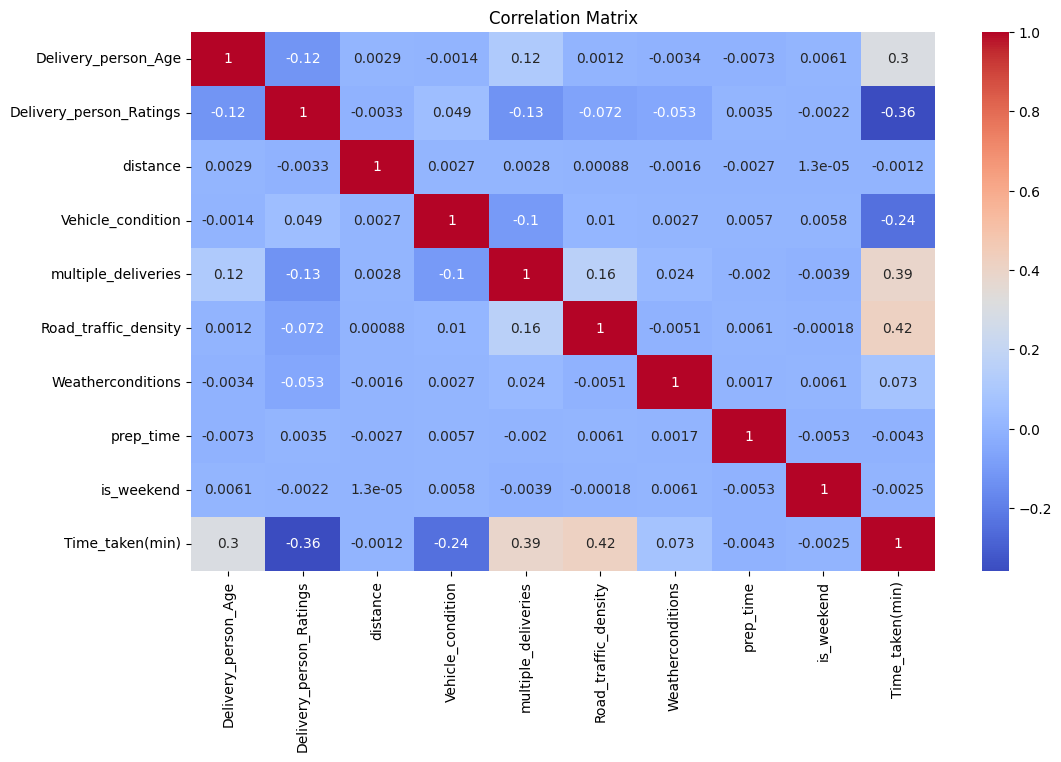

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,7))
sns.heatmap(train_df[features + ['Time_taken(min)']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

                   Feature  Importance
6        Weatherconditions   25.123837
5     Road_traffic_density   19.472086
2                 distance   16.303101
0      Delivery_person_Age   12.997510
1  Delivery_person_Ratings   10.866865
3        Vehicle_condition   10.664136
4      multiple_deliveries    4.139098
7                prep_time    0.268543
8               is_weekend    0.164825


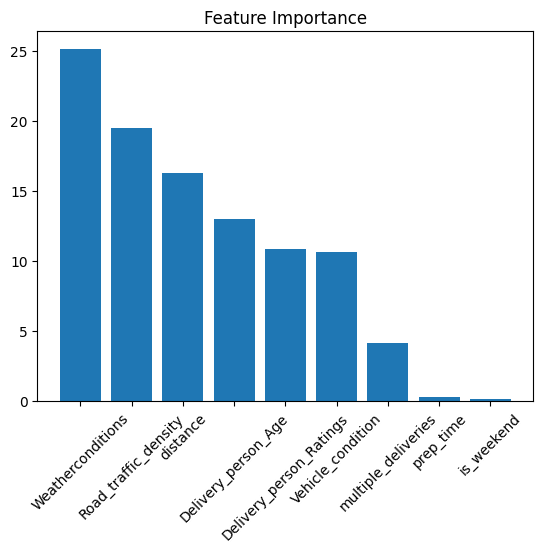

In [14]:
importance = model.feature_importances_

feat_imp = pd.DataFrame({
    "Feature": X.columns,
    "Importance": importance
}).sort_values(by="Importance", ascending=False)

print(feat_imp)

plt.figure()
plt.bar(feat_imp["Feature"], feat_imp["Importance"])
plt.xticks(rotation=45)
plt.title("Feature Importance")
plt.show()

In [17]:
import joblib

joblib.dump(model, "DeliveryTime.pkl")
joblib.dump(X.columns.tolist(), "DTFeatures.pkl")

['DTFeatures.pkl']

## Sonuç
%80 üstüne çıktık ancak modeli hayata uygulamak çok zor olacak. Göstermek için pkl kaydettim. Gerçek hayatta muhteşem bir model ancak uygulamak zor sonra başka bir uygulama da kullanacağım. 
